In [3]:
# Convert PNG images to CSV by summing pixel intensities along Y-axis
# Output CSV:
# column  = summed intensity for each x position

import os
import csv
from PIL import Image
import numpy as np

input_folder = "Images"
output_folder = "CSV_images"

os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(input_folder):
    if filename.lower().endswith(".png"):
        img_path = os.path.join(input_folder, filename)

        # Open as grayscale
        img = Image.open(img_path).convert("L")
        arr = np.array(img)   # shape = (height, width)

        # Sum along Y-axis (rows), leaving one value per X position
        x_sums = arr.sum(axis=0)

        csv_name = os.path.splitext(filename)[0] + "_sum.csv"
        csv_path = os.path.join(output_folder, csv_name)

        with open(csv_path, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["intensity"])

            for x, intensity in enumerate(x_sums):
                writer.writerow([int(intensity)])

        print(f"Saved: {csv_path}")

Saved: CSV_images\Airydisk1_sum.csv
Saved: CSV_images\Airydisk2_sum.csv
Saved: CSV_images\Airydisk3_sum.csv


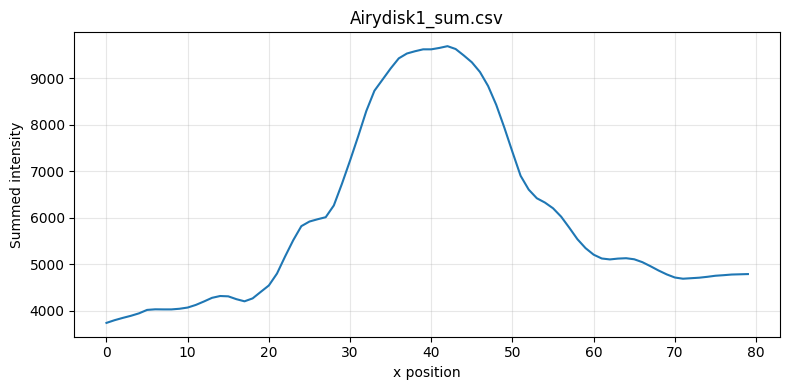

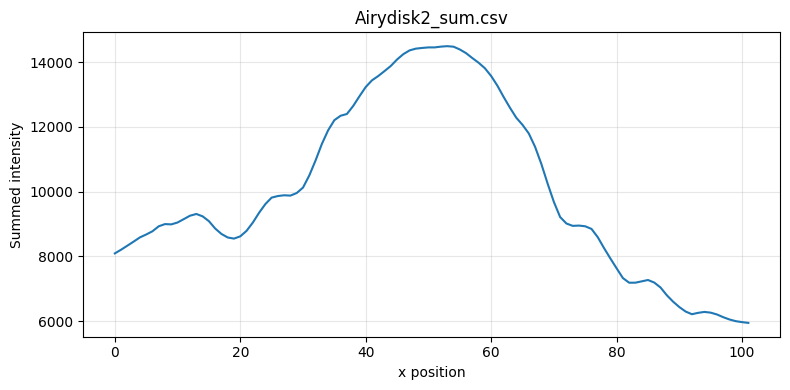

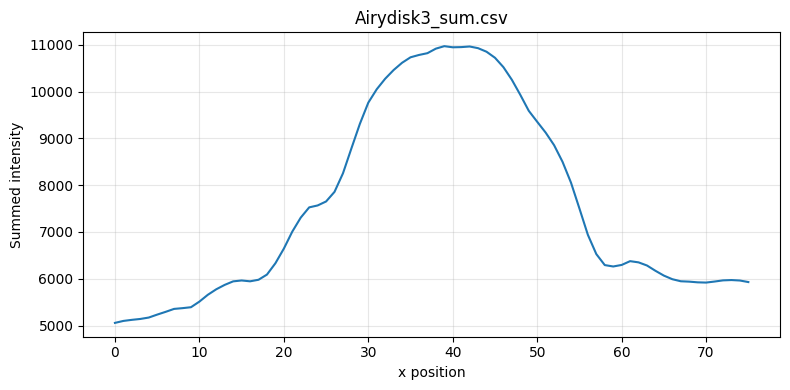

In [4]:
# Read generated CSV files and plot intensity vs x

import os
import pandas as pd
import matplotlib.pyplot as plt


def plot(files,folder_path):
    for filename in files:
       csv_path = os.path.join(folder_path, filename)
       # Read CSV
       df = pd.read_csv(csv_path)
       # Plot
       plt.figure(figsize=(8,4))
       plt.plot(df["intensity"], linewidth=1.5)
       plt.title(filename)
       plt.xlabel("x position")
       plt.ylabel("Summed intensity")
       plt.grid(True, alpha=0.3)
       plt.tight_layout()
       plt.show()

folder_path = "CSV_images"
files = ["Airydisk1_sum.csv", "Airydisk2_sum.csv","Airydisk3_sum.csv"]

plot(files,folder_path)

In [5]:
# Convert PNG images to CSV by finding the brightest pixel in the image,
# then reading out the full horizontal row through that pixel.
#
# Output CSV:
# column 2 = intensity

import os
import csv
from PIL import Image
import numpy as np

input_folder = "Images"
output_folder = "CSV_images"

os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(input_folder):
    if filename.lower().endswith(".png"):
        img_path = os.path.join(input_folder, filename)

        # Open image as grayscale
        img = Image.open(img_path).convert("L")
        arr = np.array(img)   # shape = (height, width)

        # Find brightest pixel in whole image
        peak_index = np.argmax(arr)
        peak_y, peak_x = np.unravel_index(peak_index, arr.shape)

        # Read horizontal line through brightest pixel
        row_profile = arr[peak_y, :]

        csv_name = os.path.splitext(filename)[0] + "brightestpixel.csv"
        csv_path = os.path.join(output_folder, csv_name)

        with open(csv_path, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["intensity"])

            for x, intensity in enumerate(row_profile):
                writer.writerow([int(intensity)])

        print(f"Saved: {csv_path}   (read row y = {peak_y})")

Saved: CSV_images\Airydisk1brightestpixel.csv   (read row y = 38)
Saved: CSV_images\Airydisk2brightestpixel.csv   (read row y = 36)
Saved: CSV_images\Airydisk3brightestpixel.csv   (read row y = 35)


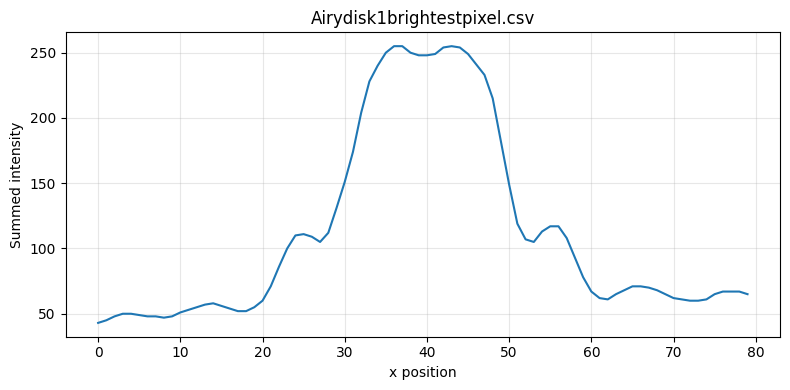

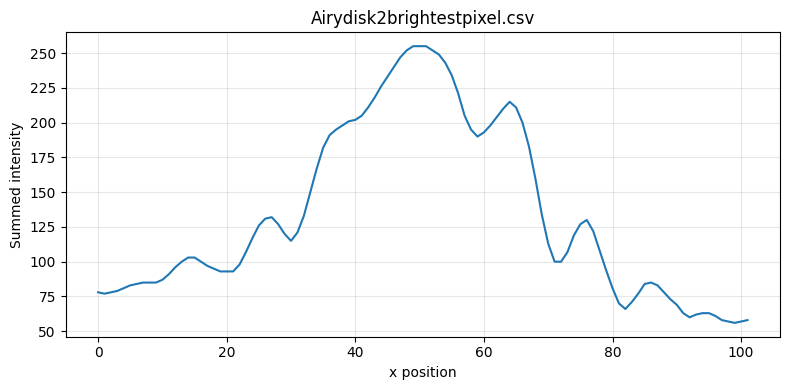

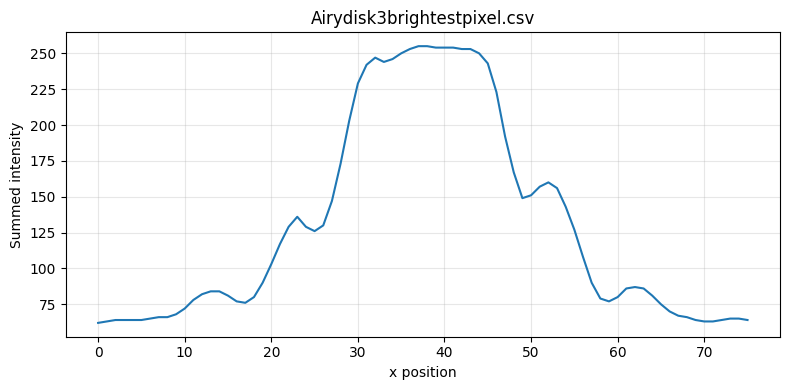

In [6]:
folder_path = "CSV_images"
files = ["Airydisk1brightestpixel.csv", "Airydisk2brightestpixel.csv","Airydisk3brightestpixel.csv"]

plot(files,folder_path)

C:\Users\eljam\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\eljam\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


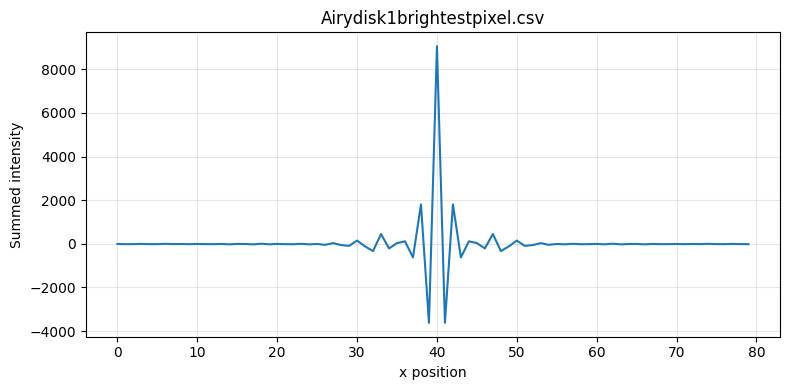

C:\Users\eljam\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\eljam\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


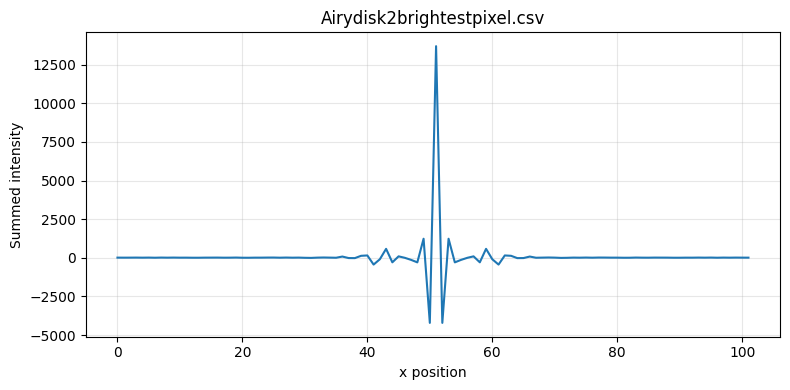

C:\Users\eljam\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\eljam\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


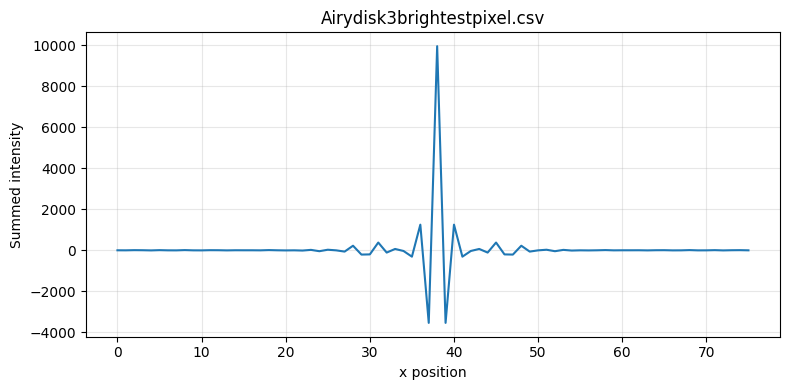

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt


def plot(files,folder_path):
    for filename in files:
       csv_path = os.path.join(folder_path, filename)
       # Read CSV
       df = pd.read_csv(csv_path)
       fft = np.fft.fftshift(np.fft.fft(df["intensity"]))
       # Plot
       plt.figure(figsize=(8,4))
       plt.plot(fft, linewidth=1.5)
       plt.title(filename)
       plt.xlabel("x position")
       plt.ylabel("Summed intensity")
       plt.grid(True, alpha=0.3)
       plt.tight_layout()
       plt.show()

folder_path = "CSV_images"
files = ["Airydisk1brightestpixel.csv", "Airydisk2brightestpixel.csv","Airydisk3brightestpixel.csv"]

plot(files,folder_path)

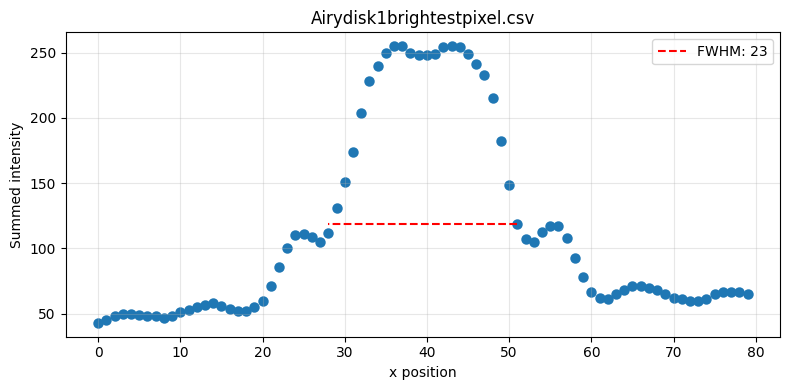

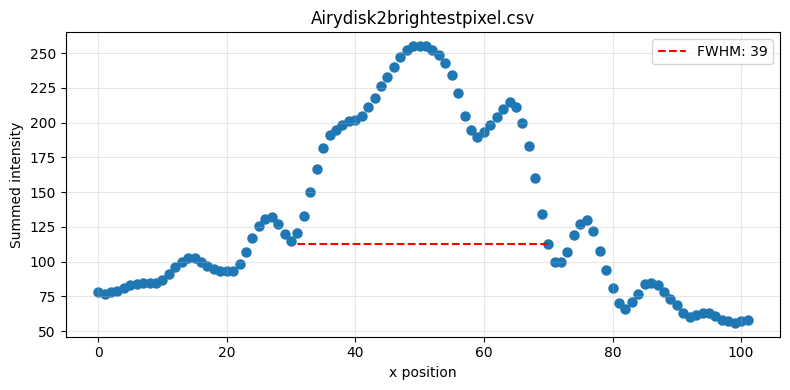

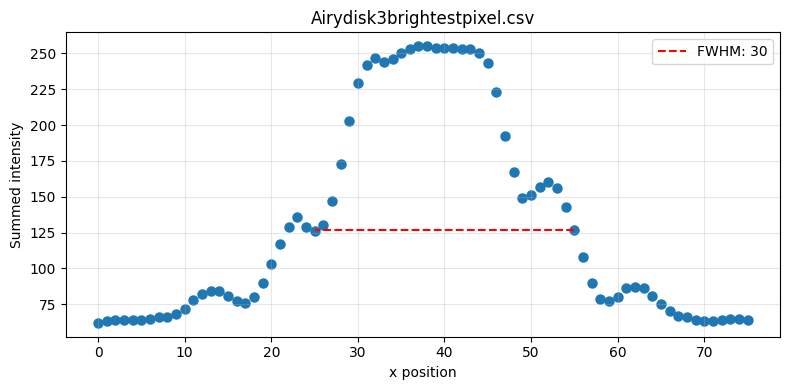

In [17]:
def fwhm(files,folder_path):
    for filename in files:
       csv_path = os.path.join(folder_path, filename)
       # Read CSV
       df = pd.read_csv(csv_path)
       y = df["intensity"].to_numpy()
       x = df.index.to_numpy()
       i = y.argmax()
       h = y[i] / 2
       l = np.where(y[:i] < h)[0][-1]
       r = i+np.where(y[i:] < h)[0][0]
       width =r-l
       # Plot
       plt.figure(figsize=(8,4))
       plt.scatter(x,y, linewidth=1.5)
       plt.hlines(y[r], r, l, linestyles="dashed", label=f"FWHM: {width}", color="red")
       plt.title(filename)
       plt.xlabel("x position")
       plt.ylabel("Summed intensity")
       plt.grid(True, alpha=0.3)
       plt.legend()
       plt.tight_layout()
       plt.show()

folder_path = "CSV_images"
files = ["Airydisk1brightestpixel.csv", "Airydisk2brightestpixel.csv","Airydisk3brightestpixel.csv"]

fwhm(files,folder_path)